# Rapport de tests — HyConEx from scratch sur DLBaC

Ce notebook présente : métriques, matrice de confusion, courbe d'apprentissage, contre-factuels et preuves de validité.

In [1]:
from pathlib import Path
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
RUN_NAME = 'report_run'

metrics_path = RESULTS / f'{RUN_NAME}_metrics.json'
history_path = RESULTS / f'{RUN_NAME}_learning_curve.csv'
pred_path = RESULTS / f'{RUN_NAME}_test_predictions.csv'
cf_path = RESULTS / f'{RUN_NAME}_counterfactuals_preview.csv'

assert metrics_path.exists(), metrics_path
assert history_path.exists(), history_path
assert pred_path.exists(), pred_path
assert cf_path.exists(), cf_path

metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
history = pd.read_csv(history_path)
pred = pd.read_csv(pred_path)
cf = pd.read_csv(cf_path)
cf['changed_features_idx'] = cf['changed_features_idx'].apply(ast.literal_eval)

print('Fichiers chargés pour:', RUN_NAME)

Fichiers chargés pour: report_run


In [2]:
# Metriques globales
summary = {
    'dataset': metrics['dataset'],
    'num_features': metrics['num_features'],
    'num_classes': metrics['num_classes'],
    'best_val_accuracy': metrics['val_best_accuracy'],
    'test_accuracy': metrics['test']['accuracy'],
    'test_auroc_ovr': metrics['test']['auroc_ovr'],
    'cf_validity': metrics['counterfactuals_test']['validity_cf'],
    'cf_proximity_l1_mean': metrics['counterfactuals_test']['proximity_l1_mean'],
    'cf_changed_features_mean': metrics['counterfactuals_test']['changed_features_mean'],
    'cf_n_evaluated': metrics['counterfactuals_test']['n_evaluated'],
}
pd.DataFrame([summary]).T.rename(columns={0: 'value'})

,value
dataset,DLBAC_u4k-r4k-auth11k
num_features,157
num_classes,16
best_val_accuracy,0.97208
test_accuracy,0.963504
test_auroc_ovr,0.999594
cf_validity,1.0
cf_proximity_l1_mean,30.342375
cf_changed_features_mean,46.431568
cf_n_evaluated,2192


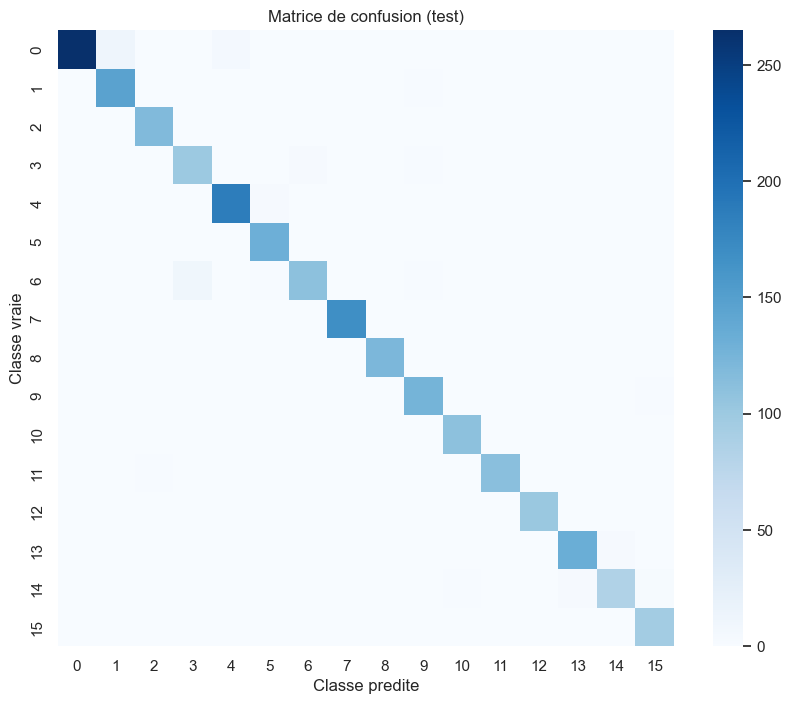

In [3]:
# Matrice de confusion
cm = np.array(metrics['test']['confusion_matrix'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues', square=True)
plt.title('Matrice de confusion (test)')
plt.xlabel('Classe predite')
plt.ylabel('Classe vraie')
plt.show()

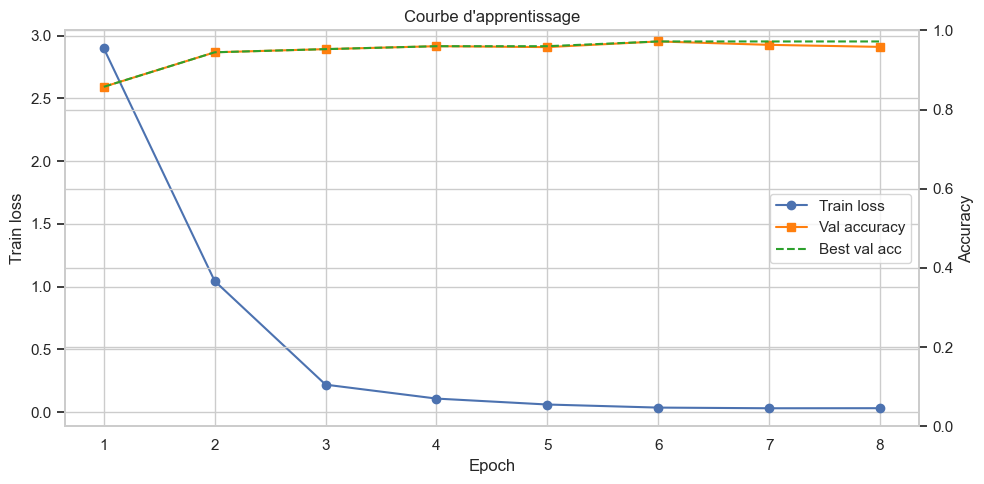

In [4]:
# Courbe d'apprentissage
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(history['epoch'], history['train_loss'], marker='o', label='Train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train loss')

ax2 = ax1.twinx()
ax2.plot(history['epoch'], history['val_accuracy'], marker='s', color='tab:orange', label='Val accuracy')
ax2.plot(history['epoch'], history['best_val_accuracy'], linestyle='--', color='tab:green', label='Best val acc')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('Courbe d\'apprentissage')
plt.tight_layout()
plt.show()

In [5]:
# Distribution des erreurs de classification
pred['is_correct'] = pred['y_true'] == pred['y_pred']
acc = pred['is_correct'].mean()
err = 1 - acc
print(f'Accuracy test re-calculée: {acc:.4f} | Erreur: {err:.4f}')

error_counts = pred.loc[~pred['is_correct']].groupby(['y_true', 'y_pred']).size().reset_index(name='n')
error_counts.sort_values('n', ascending=False).head(15)

Accuracy test re-calculée: 0.9635 | Erreur: 0.0365


,y_true,y_pred,n
0,0,1,13
13,6,3,11
2,0,4,6
6,3,6,4
8,4,5,4
27,13,14,4
29,14,13,4
30,14,15,3
7,3,9,2
28,14,10,2


In [6]:
# Contre-factuels produits (table lisible)
cf_display = cf[[
    'sample_index', 'y_true', 'y_pred_orig', 'y_target_cf', 'y_pred_cf',
    'valid_cf', 'l1_distance', 'changed_features_count'
]].copy()
cf_display = cf_display.sort_values(['valid_cf', 'l1_distance'], ascending=[False, True])
cf_display.head(20)

,sample_index,y_true,y_pred_orig,y_target_cf,y_pred_cf,valid_cf,l1_distance,changed_features_count
33,321,7,7,1,1,True,25.269543,41
21,621,8,8,0,0,True,25.924618,47
4,1393,14,14,9,9,True,26.714584,44
14,1452,1,1,11,11,True,27.060263,49
31,307,10,10,4,4,True,27.152842,41
9,100,3,3,10,10,True,27.188107,47
13,1833,8,8,11,11,True,27.389153,44
38,812,3,3,0,0,True,27.600363,46
18,1193,9,9,14,14,True,27.617195,42
15,1976,14,15,11,11,True,27.644012,46


Taux de validité CF (preview): 1.0000
Distance L1 moyenne (preview): 30.4414
Nb moyen de features modifiées: 46.77


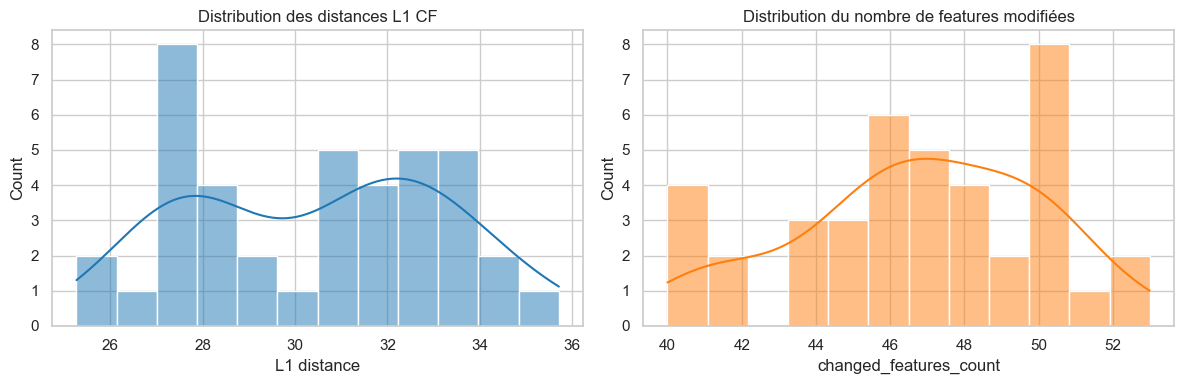

In [7]:
# Preuves de contre-factualité: validité + effort de changement
valid_rate = cf['valid_cf'].mean()
mean_l1 = cf['l1_distance'].mean()
mean_changed = cf['changed_features_count'].mean()
print(f'Taux de validité CF (preview): {valid_rate:.4f}')
print(f'Distance L1 moyenne (preview): {mean_l1:.4f}')
print(f'Nb moyen de features modifiées: {mean_changed:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(cf['l1_distance'], bins=12, kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Distribution des distances L1 CF')
axes[0].set_xlabel('L1 distance')

sns.histplot(cf['changed_features_count'], bins=12, kde=True, ax=axes[1], color='tab:orange')
axes[1].set_title('Distribution du nombre de features modifiées')
axes[1].set_xlabel('changed_features_count')

plt.tight_layout()
plt.show()

In [8]:
# Preuves locales: exemples détaillés de transitions CF
def show_local_evidence(row):
    print(f"sample={int(row['sample_index'])} | true={int(row['y_true'])} | pred_orig={int(row['y_pred_orig'])} -> target={int(row['y_target_cf'])} | pred_cf={int(row['y_pred_cf'])} | valid={bool(row['valid_cf'])}")
    print(f"l1={row['l1_distance']:.4f}, changed_count={int(row['changed_features_count'])}")
    changed = row['changed_features_idx']
    print('top indices modifiés:', changed[:12])
    print('-' * 80)

for _, r in cf.sort_values(['valid_cf', 'l1_distance'], ascending=[False, True]).head(8).iterrows():
    show_local_evidence(r)

sample=321 | true=7 | pred_orig=7 -> target=1 | pred_cf=1 | valid=True
l1=25.2695, changed_count=41
top indices modifiés: [3, 5, 6, 7, 12, 17, 19, 22, 29, 30, 37, 45]
--------------------------------------------------------------------------------
sample=621 | true=8 | pred_orig=8 -> target=0 | pred_cf=0 | valid=True
l1=25.9246, changed_count=47
top indices modifiés: [3, 5, 7, 10, 19, 20, 42, 45, 47, 48, 49, 52]
--------------------------------------------------------------------------------
sample=1393 | true=14 | pred_orig=14 -> target=9 | pred_cf=9 | valid=True
l1=26.7146, changed_count=44
top indices modifiés: [3, 7, 12, 15, 19, 24, 26, 29, 37, 45, 47, 48]
--------------------------------------------------------------------------------
sample=1452 | true=1 | pred_orig=1 -> target=11 | pred_cf=11 | valid=True
l1=27.0603, changed_count=49
top indices modifiés: [1, 3, 7, 10, 19, 22, 27, 29, 41, 45, 47, 48]
-------------------------------------------------------------------------------